The purpose of this notebook is to generate some clean equilbrium scaling plots
Potentially use cluster if its useful.



In [1]:
import sys
import os
sys.path.append("../../../src/")
#Imports
import single_particle_sector as sps
import kblock_ising_model as kb
import numpy as np
import scipy as sp
import numpy.linalg as la
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter
from collections import Counter


##Personal Imports##

from numpy import pi, cos, sin, exp, log, sqrt, array


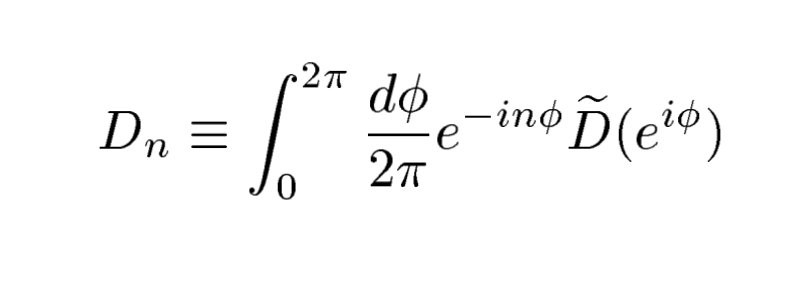

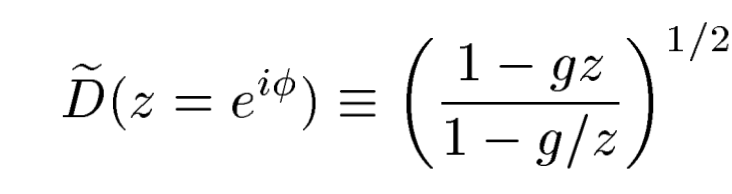

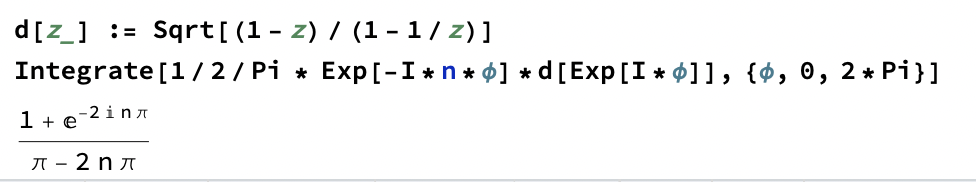

In [2]:
#Correlation Function
#Definition of this comes from sachdev
def Dn(n):
    return 2/np.pi/(1-2*n)


def sigma_general(indices):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)
    #Bs sit on odd sites
    odd_sites = np.array(indices[::2])
    #As site on even sites
    even_sites= np.array(indices[1::2])
    #Get string lengths
    JW_string_lengths = even_sites-odd_sites
    #Sum of string lengths is size of matrix needed
    N = sum(JW_string_lengths)
    #Fill in indices for strings
    R = []
    for i in range(0, len(indices), 2):
        start = indices[i]
        end = indices[i+1]
        R.extend(range(start, end+1))

    A_coords = [x for x in R if x not in odd_sites]
    B_coords = [x for x in R if x not in even_sites]
    C = np.zeros((N,N))
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = Dn(Nd)
    return np.linalg.det(C)

def P_n(n,even = True):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = kb.all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(np.abs(sigma_general(indices)))*degen)
        else:
            dat.append(sigma_general(indices)*degen)
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n

def P_n_correlations(n,l, even = True):
    #Term 1 
    indices = [i for i in range(0,n)]
    #Term 2 
    indices +=[i for i in range(n+l-1,2*n+l-1)]
    terms = kb.all_combinations(indices)
   # print(terms)
     ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))
    #
    dat = []
    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(sigma_general(indices))*degen)
        else:
            dat.append(sigma_general(indices)*degen)
    dat.append(1)
    #All terms have equal weight. 

    return np.sum(dat)/2**(2*n)#,terms


In [3]:
###correlator
def correlator_data(n,rmin,rmax):
    r_points = np.arange(rmin,rmax)
    data = array([P_n_correlations(n,r) for r in r_points])
    return [data,r_points]

import os

folder_name = "equilibrium_critical_correlation_data"

# Create the folder if it doesn't exist
if not os.path.exists(folder_name):
    os.makedirs(folder_name)


In [ ]:
import os
import numpy as np
from tqdm import tqdm
for n in tqdm(range(7,11)):
    rmin = 0
    rmax = 100

    # get only the data part
    data, _ = correlator_data(n, rmin, rmax)

    # save it
    np.save(f"{folder_name}/correlator_n{n}_r{rmin}-{rmax}.npy", data)
    # or text:
    # np.savetxt(f"data/correlator_n{n}_r{rmin}-{rmax}.txt", data)
    print(f"n = {n} completed!")


  0%|          | 0/4 [00:00<?, ?it/s]/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
 25%|██▌       | 1/4 [03:04<09:14, 184.93s/it]

n = 7 completed!


[0, 1, 2, 14, 15, 16]
